Lab 25.1 – SHAP Values
Goal: Train a tree model, compute SHAP values, and visualize:

global importance (bar / beeswarm),

per‑feature effects (dependence plot),

local explanations for single predictions (force plot / waterfall).

We’ll use Titanic (classification) with a Random Forest.
SHAP is model‑agnostic, but TreeExplainer is fast/accurate for tree models.

In [2]:
# pip install shap scikit-learn pandas numpy seaborn matplotlib
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import shap
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

# (in some environments) to render JS plots inline
shap.initjs()

C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1) Data & pipeline (no leakage)

In [3]:
df = sns.load_dataset('titanic').drop(columns=['alive'])
target = 'survived'
features = ['pclass','sex','age','sibsp','parch','fare','embarked','class','who','alone']
df = df[features + [target]].copy()
df[target] = df[target].astype(int)

X = df[features]
y = df[target]

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

clf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=1,
    random_state=0, n_jobs=-1
)

pipe = Pipeline([('prep', prep), ('rf', clf)])

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
pipe.fit(X_tr, y_tr)

proba = pipe.predict_proba(X_te)[:,1]
print("Hold‑out Acc:", round(accuracy_score(y_te, pipe.predict(X_te)),3))
print("Hold‑out ROC‑AUC:", round(roc_auc_score(y_te, proba),3))

Hold‑out Acc: 0.827
Hold‑out ROC‑AUC: 0.834


2) Get transformed feature matrix & names
SHAP explains the model’s input space (post‑preprocessing). We’ll transform X_te and recover the one‑hot feature names.

In [4]:
# Transformed arrays
Xt_tr = pipe.named_steps['prep'].transform(X_tr)
Xt_te = pipe.named_steps['prep'].transform(X_te)

# Feature names after preprocessing
oh = pipe.named_steps['prep'].named_transformers_['cat'].named_steps['oh']
feat_names = list(num_cols) + oh.get_feature_names_out(cat_cols).tolist()
len(feat_names), Xt_te.shape

(18, (179, 18))

3) Build a SHAP explainer
Use TreeExplainer on the fitted Random Forest (fast & exact-ish for tree models).

In [6]:
import numpy as np
import shap

# 1. Prepare the background data FIRST
# Assuming Xt_tr is your transformed training data
bg_idx = np.random.choice(Xt_tr.shape[0], size=min(500, Xt_tr.shape[0]), replace=False)
background = Xt_tr[bg_idx]

# 2. Get the model from the pipeline
rf_model = pipe.named_steps['rf']

# 3. Initialize the explainer WITH the 'data' argument
# Providing 'data' enables feature_perturbation="interventional", 
# which allows model_output="probability"
explainer = shap.TreeExplainer(
    rf_model, 
    data=background, 
    feature_names=feat_names, 
    model_output="probability"
)

# 4. Calculate SHAP values (example usage)
# shap_values = explainer(Xt_tr[0:10])


Compute SHAP values on the test set:

In [7]:
# shap_values shape: (n_samples, n_features)
shap_values = explainer.shap_values(Xt_te, check_additivity=False)  # suppress additivity warning for prob output
# For scikit-learn RF classifier with TreeExplainer(model_output='probability'),
# shap_values is array for class-1 if binary; unify to 2D matrix if needed:
if isinstance(shap_values, list):  # some versions return [class0, class1]
    shap_values = shap_values[1]
shap_values.shape

 96%|=================== | 342/358 [00:20<00:00]       

(179, 18, 2)

4) Global importance: bar + beeswarm

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15916\3588656062.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, Xt_te, feature_names=feat_names, plot_type='bar', show=True)
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new 

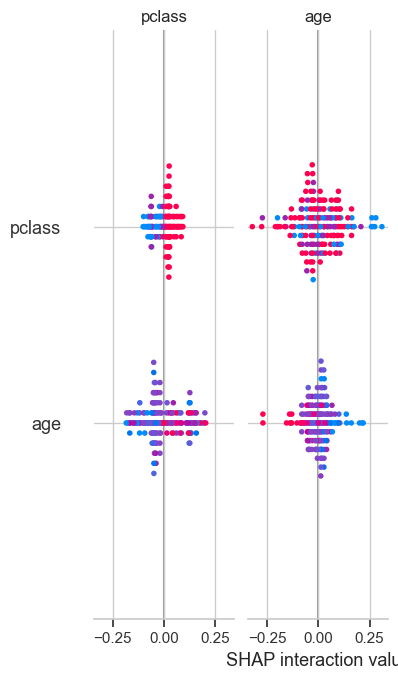

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15916\3588656062.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, Xt_te, feature_names=feat_names, show=True)
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and sil

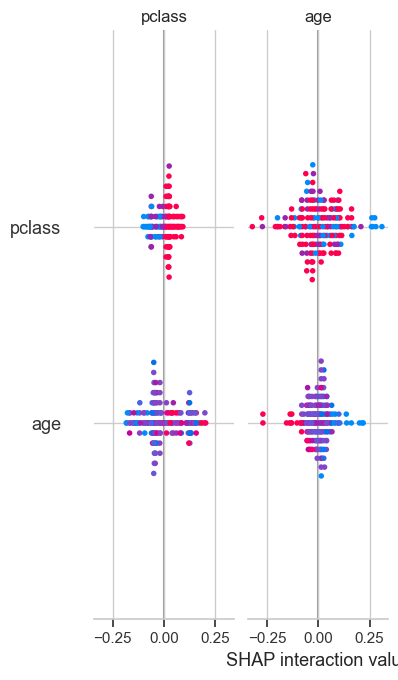

In [8]:
# Bar (mean |SHAP| per feature)
shap.summary_plot(shap_values, Xt_te, feature_names=feat_names, plot_type='bar', show=True)

# Beeswarm (distribution of contributions per feature)
shap.summary_plot(shap_values, Xt_te, feature_names=feat_names, show=True)

Read me:

Bar = average absolute impact on predictions.

Beeswarm encodes magnitude (x) and feature value (color). One‑hot features appear as separate columns (e.g., sex_female).

5) Per‑feature effect: dependence plot
Pick a top feature from the bar chart and (optionally) add an interaction feature.

In [10]:
import pandas as pd
import numpy as np

# 1. Check if shap_values has 3 dimensions (samples, features, classes)
# If so, select the positive class (usually index 1)
if shap_values.ndim == 3:
    # shape becomes (samples, features)
    shap_values_class = shap_values[:, :, 1]
else:
    shap_values_class = shap_values

# 2. Calculate mean absolute SHAP values on the 2D array
mean_shap_values = np.abs(shap_values_class).mean(axis=0)

# 3. Create the Series (now the data is 1D, matching feat_names)
top_feat = pd.Series(mean_shap_values, index=feat_names).sort_values(ascending=False).index[0]

print("Top feature:", top_feat)


Top feature: who_man


6) Local explanations: single prediction
Explain why one specific passenger’s predicted probability is what it is.

Passenger idx: 5
Base Value (Average Probability): 0.405
Predicted Probability: 0.295

Waterfall Plot:


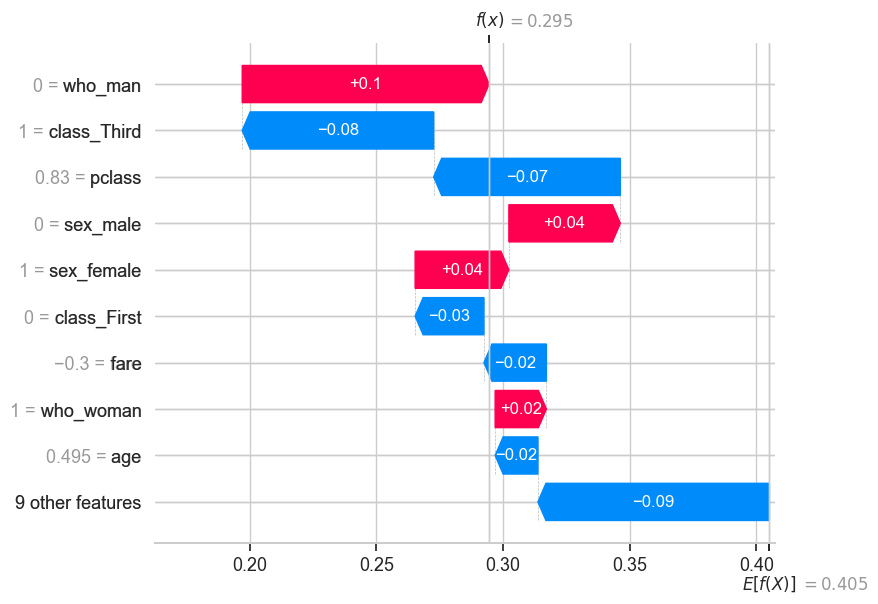


Force Plot:


In [12]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Initialize JS for force_plot
shap.initjs()

i = 5  # index in the test set to inspect
class_idx = 1  # 1 = Positive class (Survived), 0 = Negative class

# 1. Prepare Data
# row needs to be 1D for the plots: shape (n_features,)
row_values = Xt_te[i] 

# 2. Prepare Base Value (Expected Value)
# If expected_value is an array [prob_class_0, prob_class_1], pick class 1
if isinstance(explainer.expected_value, np.ndarray) or isinstance(explainer.expected_value, list):
    base_value = explainer.expected_value[class_idx]
else:
    base_value = explainer.expected_value

# 3. Prepare SHAP Values
# If shap_values is 3D (samples, features, classes), slice for class 1
if shap_values[i].ndim == 2:
    shap_values_instance = shap_values[i][:, class_idx]
else:
    shap_values_instance = shap_values[i]

print(f"Passenger idx: {i}")
print(f"Base Value (Average Probability): {base_value:.3f}")
print(f"Predicted Probability: {base_value + shap_values_instance.sum():.3f}")

# --- PLOTTING ---

# 4. Waterfall Plot
# Construct a specific Explanation object for this single instance
exp_single = shap.Explanation(
    values=shap_values_instance,
    base_values=base_value,
    data=row_values,
    feature_names=feat_names
)

print("\nWaterfall Plot:")
# Use the modern plotting function instead of _waterfall_legacy
shap.plots.waterfall(exp_single)

# 5. Force Plot
print("\nForce Plot:")
shap.force_plot(
    base_value, 
    shap_values_instance, 
    row_values, 
    feature_names=feat_names,
    matplotlib=False # Set to True if you want a static image instead of JS
)


Interpretation: The base value is the average predicted probability on the background data.
Positive SHAP pushes the prediction up (toward survival), negative pushes down.

7) Tips, caveats, and alternatives
Tree models → TreeExplainer (fast, consistent).

Linear models → shap.LinearExplainer (coefficients × standardized features).

Any model → shap.KernelExplainer (model‑agnostic but slow; sample background & points).

One‑hot features: interpret groups (e.g., embarked_*) together for narratives.

SHAP explains a specific model on a specific feature space—keep your pipeline consistent.

8) (Optional) Model‑agnostic demo (KernelExplainer, small sample)

100%|██████████| 50/50 [00:17<00:00,  2.94it/s]
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_15916\706287174.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_small, Xt_te[small_idx], feature_names=feat_names, show=True)


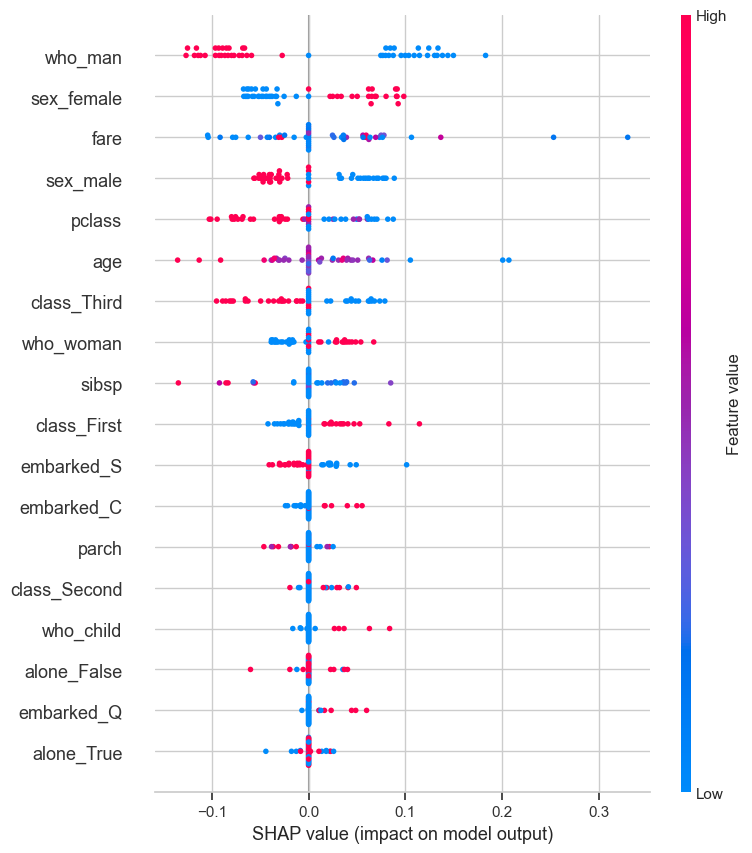

In [13]:
# WARNING: slow for many samples/features — keep tiny!
small_idx = np.random.choice(Xt_te.shape[0], size=50, replace=False)
f = lambda A: rf_model.predict_proba(A)[:,1]
kexp = shap.KernelExplainer(f, background[:100])  # background subset
shap_vals_small = kexp.shap_values(Xt_te[small_idx], nsamples=200)
shap.summary_plot(shap_vals_small, Xt_te[small_idx], feature_names=feat_names, show=True)

Swap model: Replace RandomForest with XGBClassifier (or HistGradientBoostingClassifier), recompute SHAP via TreeExplainer, and compare the top‑10 features—are the stories consistent?

In [15]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import shap

# 1. Train XGBoost (Swap model)
# We use the same transformed training data (Xt_tr)
xgb_model = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(Xt_tr, y_tr)

# 2. Recompute SHAP for XGBoost
# XGBoost is natively supported by TreeExplainer and is usually very fast.
# We use the default model_output="raw" (log-odds) here, which is standard for ranking importance.
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(Xt_te)

# 3. Process XGB SHAP values
# XGBoost binary shap_values are typically shape (n_samples, n_features)
if isinstance(shap_values_xgb, list):
    vals_xgb = shap_values_xgb[1] # Positive class if list
elif shap_values_xgb.ndim == 3:
    vals_xgb = shap_values_xgb[:, :, 1] # Positive class if 3D
else:
    vals_xgb = shap_values_xgb # Already 2D (log-odds for positive class)

# Calculate Mean Absolute SHAP for XGB
xgb_importance = pd.Series(
    np.abs(vals_xgb).mean(axis=0),
    index=feat_names
).sort_values(ascending=False)

# 4. Process RF SHAP values (from previous context) for comparison
# We handle the dimensions of the previous RF shap_values to ensure fair comparison
if 'shap_values' in locals():
    # Handle potential 3D shape from previous probability output
    if isinstance(shap_values, list):
        vals_rf = shap_values[1]
    elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        vals_rf = shap_values[:, :, 1]
    else:
        vals_rf = shap_values

    rf_importance = pd.Series(
        np.abs(vals_rf).mean(axis=0),
        index=feat_names
    ).sort_values(ascending=False)

    # 5. Create Comparison DataFrame
    comparison_df = pd.DataFrame({
        'RF_Feature': rf_importance.index[:10],
        'XGB_Feature': xgb_importance.index[:10],
        'RF_Mean_SHAP': rf_importance.values[:10],
        'XGB_Mean_SHAP': xgb_importance.values[:10]
    })
    
    print("--- Top 10 Features Comparison ---")
    # Use display() if in Jupyter, otherwise print()
    try:
        display(comparison_df)
    except NameError:
        print(comparison_df)

    # Calculate Overlap
    top_10_rf = set(rf_importance.index[:10])
    top_10_xgb = set(xgb_importance.index[:10])
    overlap = len(top_10_rf.intersection(top_10_xgb))
    print(f"\nConsistency Check: {overlap}/10 features overlap in the top 10.")
else:
    print("Previous RF shap_values not found. Showing XGB top 10:")
    print(xgb_importance.head(10))


--- Top 10 Features Comparison ---


,RF_Feature,XGB_Feature,RF_Mean_SHAP,XGB_Mean_SHAP
0,who_man,who_man,0.098201,1.447225
1,fare,fare,0.063624,1.041202
2,sex_female,pclass,0.052863,0.877380
3,age,age,0.045015,0.721085
4,sex_male,sex_female,0.044508,0.408439
5,pclass,embarked_S,0.040323,0.259185
6,class_Third,sibsp,0.036359,0.169683
7,who_woman,embarked_C,0.028741,0.169306
8,class_First,parch,0.022359,0.104652
9,sibsp,alone_False,0.021059,0.100524



Consistency Check: 6/10 features overlap in the top 10.


Group one‑hot features: Aggregate SHAP across levels of a categorical (e.g., sum embarked_*). Which original categorical contributes most globally?

In [16]:
import pandas as pd
import numpy as np

# 1. Prepare SHAP values (Ensure 2D array: n_samples x n_features)
# If using the previous probability output (3D), select the positive class (index 1)
if 'shap_values' in locals():
    if isinstance(shap_values, list): # LightGBM/RF sometimes return list
        vals = shap_values[1]
    elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        vals = shap_values[:, :, 1]
    else:
        vals = shap_values # Already 2D (e.g. XGBoost raw output)
else:
    raise ValueError("shap_values not found in context.")

# 2. Group features by their original prefix
# We assume OHE features follow a pattern like "Prefix_Value" (e.g., "Embarked_S")
feature_groups = {}

for i, col in enumerate(feat_names):
    # Logic: Split by the first underscore to find the parent feature
    # Adjust this logic if your column names don't use underscores
    if "_" in col:
        original_name = col.split("_")[0]
    else:
        original_name = col
        
    if original_name not in feature_groups:
        feature_groups[original_name] = []
    feature_groups[original_name].append(i)

# 3. Aggregate SHAP values and calculate Global Importance
aggregated_importance = {}

for original_name, indices in feature_groups.items():
    # Step A: Sum SHAP values across the group for each instance
    # This reconstructs the single vector for the original feature
    # shape: (n_samples,)
    reconstructed_shap_vec = vals[:, indices].sum(axis=1)
    
    # Step B: Calculate Mean Absolute Value (Global Importance)
    aggregated_importance[original_name] = np.abs(reconstructed_shap_vec).mean()

# 4. Display Results
agg_imp_series = pd.Series(aggregated_importance).sort_values(ascending=False)

print("--- Global Feature Importance (Aggregated) ---")
print(agg_imp_series)

top_cat = agg_imp_series.index[0]
print(f"\nThe original categorical feature that contributes most globally is: '{top_cat}'")


--- Global Feature Importance (Aggregated) ---
who         0.132288
sex         0.097371
fare        0.063624
class       0.062769
age         0.045015
pclass      0.040323
embarked    0.031206
sibsp       0.021059
alone       0.017337
parch       0.009950
dtype: float64

The original categorical feature that contributes most globally is: 'who'


Fairness slice: Compute mean |SHAP| by subgroup (e.g., sex_female vs sex_male) on the test set. Are explanations systematically different?

In [17]:
import pandas as pd
import numpy as np

# 1. Standardize SHAP values to 2D (n_samples, n_features)
# If 3D (probability output), select the positive class (index 1)
if 'shap_values' in locals():
    if isinstance(shap_values, list):
        vals = shap_values[1]
    elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        vals = shap_values[:, :, 1]
    else:
        vals = shap_values
else:
    raise ValueError("shap_values variable not found.")

# 2. Identify the Subgroup Column
# We need to find the index of the feature defining the group (e.g., 'Sex_female')
# Adjust 'group_col' to match your exact one-hot encoded feature name
group_col = 'Sex_female' 

if group_col not in feat_names:
    # Fallback: try to find a column that looks like it
    candidates = [f for f in feat_names if 'Sex' in f or 'female' in f]
    if candidates:
        group_col = candidates[0]
        print(f"'{group_col}' not found exactly. Using '{candidates[0]}' instead.")
    else:
        raise ValueError(f"Could not find a column for grouping (e.g., {group_col}) in feat_names.")

group_idx = feat_names.index(group_col)

# 3. Create Masks for Subgroups
# Xt_te is likely a numpy array. We use the column index to mask.
# Group A: Feature == 1 (e.g., Female)
# Group B: Feature == 0 (e.g., Male)
mask_a = Xt_te[:, group_idx] == 1
mask_b = Xt_te[:, group_idx] == 0

# 4. Compute Mean |SHAP| for each group
# We calculate the mean of absolute values for every feature, but only for rows in that group
importance_a = np.abs(vals[mask_a]).mean(axis=0)
importance_b = np.abs(vals[mask_b]).mean(axis=0)

# 5. Create Comparison DataFrame
fairness_df = pd.DataFrame({
    'Feature': feat_names,
    f'Imp_Group_A ({group_col}=1)': importance_a,
    f'Imp_Group_B ({group_col}=0)': importance_b
})

# Calculate the absolute difference in importance
fairness_df['Diff'] = np.abs(fairness_df.iloc[:, 1] - fairness_df.iloc[:, 2])

# Sort by the biggest divergence in explanation
fairness_df = fairness_df.sort_values('Diff', ascending=False).reset_index(drop=True)

print(f"--- Fairness Analysis: Feature Importance by Subgroup ({group_col}) ---")
print(f"Group A count: {sum(mask_a)}, Group B count: {sum(mask_b)}\n")

# Display top 10 features where the model reasoning differs most
try:
    display(fairness_df.head(10))
except NameError:
    print(fairness_df.head(10))


'sex_female' not found exactly. Using 'sex_female' instead.
--- Fairness Analysis: Feature Importance by Subgroup (sex_female) ---
Group A count: 61, Group B count: 118



,Feature,Imp_Group_A (sex_female=1),Imp_Group_B (sex_female=0),Diff
0,class_Third,0.070841,0.018533,0.052308
1,pclass,0.067330,0.026362,0.040967
2,who_man,0.118604,0.087653,0.030951
3,sex_female,0.070538,0.043726,0.026812
4,fare,0.047209,0.072110,0.024900
5,sex_male,0.060124,0.036435,0.023689
6,who_woman,0.039257,0.023304,0.015953
7,class_Second,0.017218,0.004814,0.012404
8,age,0.038439,0.048415,0.009976
9,embarked_S,0.020194,0.014021,0.006172
